In [13]:
from models.vqvae_single import VQVAE_Single
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision
from torch.utils.data.dataloader import DataLoader
from datasets.instance_info import InstanceInfo
from utils.metrics import calc_iou
from datasets.mask_level_dataset import MaskLevelDataset

import argparse

from datasets.coco_lvis import LvisDataset
from datasets.hqseg44k import HQSeg44KTestDataset, HQSeg44KTrainDataset

from maskseg_build_everything import build_vqvae_single, build_vqvae_single_4_stages, build_vqvae_single_4_stages_v2, build_vqvae_single_fewer_stages
from typing import List, Optional, Dict, Tuple
from utils.metrics import calc_iou
from tqdm import tqdm
import os
from itertools import islice

class BadCase:

    def __init__(self, batch_ind, ind, gt_normalized, recons_normalized):
        self.batch_ind = batch_ind
        self.ind = ind
        self.gt_normalized = gt_normalized
        self.recons_normalized = recons_normalized

class VQVAE_Evaluator:

    def __init__(self, vqvae: VQVAE_Single, batch_size=4, low_iou_thresh=0.9, device='cpu'):
        self.vqvae = vqvae
        self.device = device

        self.batch_size = batch_size
        self.low_iou_thresh = low_iou_thresh
    
    def eval_dataset(self, dataset: LvisDataset | HQSeg44KTestDataset | HQSeg44KTrainDataset):
        self.vqvae.to(self.device)
        self.vqvae.eval()

        bad_cases: List[BadCase] = []
        iou_list = []
        min_iou, max_iou = 1, 0
        nan_count = 0

        mask_level_ds = MaskLevelDataset(
            dataset=dataset,
            sam_encoder=None,
            device=self.device,
            with_image_embed=False
        )
        mask_level_dl = DataLoader(mask_level_ds, self.batch_size, shuffle=False)
        mask_level_dl = islice(mask_level_dl, 44, 45) # for debugging
        for ind, (image, image_embed_sam, single_mask_normalized, single_mask) in tqdm(enumerate(mask_level_dl)):
            single_mask_normalized = single_mask_normalized.to(self.device)
            with torch.no_grad():
                results = self.vqvae.img_to_reconstructed_img(single_mask_normalized)
            B = results[-1].shape[0]
            ious, nan_count = calc_iou(results[-1], single_mask_normalized, return_nan_count=True)
            nan_count += nan_count.item()
            for i in range(B):
                if ious[i] <= self.low_iou_thresh:
                    bad_cases.append(BadCase(
                        batch_ind=ind,
                        ind=i,
                        gt_normalized=single_mask_normalized[i].to('cpu'),
                        recons_normalized=results[-1][i].to('cpu')
                    ))
                min_iou = min(ious[i].item(), min_iou)
                max_iou = max(ious[i].item(), max_iou)
            m_iou = torch.mean(ious).item()
            assert not np.isnan(m_iou)
            iou_list.append(m_iou)
            if ind % 50 == 0:
                torch.cuda.empty_cache()
        mean_iou = np.mean(iou_list)
        return mean_iou, min_iou, max_iou, bad_cases, nan_count

    def analyze_bad_cases(self, bad_cases: List[BadCase], visualize_dir: str):
        # check if the directory exists
        if not os.path.exists(visualize_dir):
            os.makedirs(visualize_dir)

        for bad_case in bad_cases:
            chw = self.visualize(bad_case)
            chw.save(f'{visualize_dir}/{bad_case.batch_ind}_{bad_case.ind}.png')

    def visualize(self, bad_case: BadCase):
        gt = (bad_case.gt_normalized > 0).to(torch.long)
        recons = (bad_case.recons_normalized > 0).to(torch.long)
        print(gt.shape, recons.shape)
        chw = torchvision.utils.make_grid(torch.stack([gt, recons]), nrow=2, padding=1, pad_value=1.0)
        chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
        chw = Image.fromarray(chw.astype(np.uint8))
        return chw

In [6]:
checkpoint = 'ckpt/vqvae_single.pth'
vqvae_config = 'single'
dataset = 'hqseg44k_val'
batch_size = 8
low_iou_thresh = 0.9
device = 'cpu'
visualize_dir = None

if vqvae_config == 'single':
    build_vqvae = build_vqvae_single
elif vqvae_config == 'single_4_stages':
    build_vqvae = build_vqvae_single_4_stages
elif vqvae_config == 'single_4_stages_v2':
    build_vqvae = build_vqvae_single_4_stages_v2
elif vqvae_config == 'fewer_stages':
    build_vqvae = build_vqvae_fewer_stages
else:
    raise ValueError(f'Unknown vqvae config: {vqvae_config}')

vqvae = build_vqvae(checkpoint)
evaluator = VQVAE_Evaluator(vqvae, batch_size, low_iou_thresh, device)
if dataset == 'lvis_val':
    dataset = LvisDataset(dataset_path='data/coco_lvis', split='val', img_split='val')
elif dataset == 'hqseg44k_val':
    dataset = HQSeg44KTestDataset(data_root='data/sam-hq')
elif dataset == 'hqseg44k_train':
    dataset = HQSeg44KTrainDataset(data_root='data/sam-hq')
else:
    raise ValueError(f'Unknown dataset: {dataset}')

mean_iou, min_iou, max_iou, bad_cases, nan_count = evaluator.eval_dataset(dataset)
print(f'mean iou: {mean_iou}, min iou: {min_iou}, max iou: {max_iou}')
print(f'nan count: {nan_count}')

Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 555410.12it/s]
1it [00:44, 44.34s/it]

mean iou: 0.9818690419197083, min iou: 0.859736979007721, max iou: 1.0
nan count: 0


In [14]:
chw = evaluator.visualize(bad_cases[0])

torch.Size([1, 256, 256]) torch.Size([1, 256, 256])


In [32]:
gt_norm = (bad_cases[0].gt_normalized > 0).to(torch.float)
recons_norm = (bad_cases[0].recons_normalized > 0).to(torch.float)

img = torchvision.utils.make_grid(torch.stack([gt_norm, recons_norm], dim=0), nrow=2, padding=1, pad_value=1.0)
torchvision.utils.save_image(img, 'gt_recons.png')

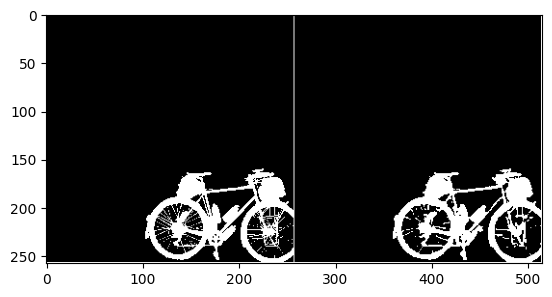

In [31]:
plt.imshow(img.permute(1, 2, 0).cpu().numpy())